# 03 — Model Training & Comparison

Loads pre-built feature tables from `./data/` and runs the full modelling pipeline.

## Experimental design (2 × 2)

| Config | Features | Training window | Purpose |
|--------|----------|-----------------|---------|
| **control** | Team-only | 2006–2014 | Anchor: same window as treatment2 |
| **treatment1** | Team-only | 1998–2014 | Effect of **more samples** (same features) |
| **treatment2** | Team + Player/Squad | 2006–2014 | Effect of **more features** (same window) |

Comparisons:
- `control` vs `treatment1` → does extending the training window help?
- `control` vs `treatment2` → does adding player/squad features help?

## Evaluation protocol
- **Fav/und perspective:** higher-Elo team = favourite
- **3-class label:** `fav_wins` / `draw` / `fav_loses`
- **LOTO CV** (Leave-One-Tournament-Out) for model selection
- **Holdout:** 2018 + 2022 (joint, never seen during training)


In [28]:
import warnings

warnings.filterwarnings("ignore")

import sqlite3, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

import lightgbm as lgb
import xgboost as xgb

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42

BASE = Path("../../../../")
DB_PATH = BASE / "data/raw/worldcup/data-sqlite/worldcup.db"
DATA = Path("./data")
assert DB_PATH.is_file()
assert (DATA / "features_team.parquet").is_file(), "Run 01_features_team.ipynb first"
assert (
    DATA / "features_player_squad.parquet"
).is_file(), "Run 02_features_player_squad.ipynb first"
print("All inputs found.")

All inputs found.


## B1 — Load feature tables & matches

In [29]:
feat_team = pd.read_parquet(DATA / "features_team.parquet")
feat_ps = pd.read_parquet(DATA / "features_player_squad.parquet")

# Load match results from DB
con = sqlite3.connect(DB_PATH)


def _sql(q):
    return pd.read_sql_query(q, con)


matches = _sql("SELECT * FROM matches")
tournaments = _sql("SELECT tournament_id, tournament_name, year FROM tournaments")
teams_db = _sql("SELECT team_id, confederation_id, team_name FROM teams")
ta = _sql(
    "SELECT tournament_id, match_id, team_id, win, draw, lose, goals_for, goals_against FROM team_appearances"
)
con.close()

matches["match_dt"] = pd.to_datetime(
    matches["match_date"], unit="D", origin="unix", errors="coerce"
)
# Exclude Women's tournaments (both Men's & Women's WC use 'WC-' prefix in this DB)
men_ids = tournaments.loc[
    ~tournaments["tournament_name"].str.contains("Women", case=False, na=False),
    "tournament_id",
].unique()
matches = matches[matches["tournament_id"].isin(men_ids)].copy()
matches = matches.merge(
    tournaments[["tournament_id", "year"]], on="tournament_id", how="left"
)

print(
    f"feat_team : {feat_team.shape}  years: {sorted(feat_team['year'].dropna().unique().astype(int))}"
)
print(
    f"feat_ps   : {feat_ps.shape}   years: {sorted(feat_ps['year'].dropna().unique().astype(int))}"
)
print(f"matches   : {matches.shape}")

feat_team : (489, 49)  years: [np.int64(1930), np.int64(1934), np.int64(1938), np.int64(1950), np.int64(1954), np.int64(1958), np.int64(1962), np.int64(1966), np.int64(1970), np.int64(1974), np.int64(1978), np.int64(1982), np.int64(1986), np.int64(1990), np.int64(1994), np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]
feat_ps   : (158, 25)   years: [np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]
matches   : (964, 30)


## B2 — Build match-level features + fav/und framing

For each match we attach home and away team features, then relabel to
**favourite** (higher pre-tournament Elo) vs **underdog** perspective.

Match-specific features added here:
- `is_host_nation` (home / away)
- `same_confederation`
- `rest_days_diff`


In [30]:
def _norm(s):
    return s.astype(str).str.strip().str.lower().str.replace(" ", "", regex=False)


# Schedule: rest days per team within tournament
sched = matches[
    ["match_id", "tournament_id", "home_team_id", "away_team_id", "match_dt", "year"]
].copy()
long = pd.concat(
    [
        sched.rename(columns={"home_team_id": "team_id", "away_team_id": "opp_id"}),
        sched.rename(columns={"away_team_id": "team_id", "home_team_id": "opp_id"}),
    ],
    ignore_index=True,
).sort_values(["tournament_id", "team_id", "match_dt", "match_id"])
long["prev_dt"] = long.groupby(["tournament_id", "team_id"])["match_dt"].shift(1)
long["rest_days"] = (long["match_dt"] - long["prev_dt"]).dt.days
rest_home = long.rename(
    columns={"team_id": "home_team_id", "rest_days": "home_rest_days"}
)
rest_away = long.rename(
    columns={"team_id": "away_team_id", "rest_days": "away_rest_days"}
)
matches = matches.merge(
    rest_home[["match_id", "home_team_id", "home_rest_days"]],
    on=["match_id", "home_team_id"],
    how="left",
)
matches = matches.merge(
    rest_away[["match_id", "away_team_id", "away_rest_days"]],
    on=["match_id", "away_team_id"],
    how="left",
)

# Host nation flags
tourn_host = tournaments.rename(
    columns={"year": "tourn_year"}
)  # already have year in matches
matches = matches.merge(
    tourn_host[["tournament_id"]].merge(
        pd.read_sql_query(
            "SELECT tournament_id, host_country FROM tournaments",
            sqlite3.connect(DB_PATH),
        ),
        on="tournament_id",
        how="left",
    ),
    on="tournament_id",
    how="left",
)
matches["home_name"] = matches["home_team_id"].map(
    teams_db.set_index("team_id")["team_name"]
)
matches["away_name"] = matches["away_team_id"].map(
    teams_db.set_index("team_id")["team_name"]
)
matches["feat_home_is_host"] = (
    _norm(matches["home_name"]) == _norm(matches["host_country"].fillna(""))
).astype(int)
matches["feat_away_is_host"] = (
    _norm(matches["away_name"]) == _norm(matches["host_country"].fillna(""))
).astype(int)

print(f"matches with schedule features: {matches.shape}")

matches with schedule features: (964, 37)


In [31]:
# Join team features (home side)
ft_home = feat_team.add_prefix("home_").rename(
    columns={"home_tournament_id": "tournament_id", "home_team_id": "home_team_id"}
)
ft_away = feat_team.add_prefix("away_").rename(
    columns={"away_tournament_id": "tournament_id", "away_team_id": "away_team_id"}
)

df_all = matches.merge(ft_home, on=["tournament_id", "home_team_id"], how="left")
df_all = df_all.merge(ft_away, on=["tournament_id", "away_team_id"], how="left")

# Same confederation flag
df_all["feat_same_confederation"] = (
    df_all["home_confederation_id"] == df_all["away_confederation_id"]
).astype(int)

print(f"df_all after team features: {df_all.shape}")

df_all after team features: (964, 132)


In [32]:
# ── Fav / Und framing ─────────────────────────────────────────────────────
# Favourite = higher pre-tournament Elo. If Elo missing, use FIFA rank (lower = better).
# Relabel columns: fav_* / und_*

home_elo = df_all["home_elo_rating"].fillna(0)
away_elo = df_all["away_elo_rating"].fillna(0)
home_is_fav = home_elo >= away_elo  # ties go to home

team_cols = [
    c
    for c in feat_team.columns
    if c
    not in (
        "tournament_id",
        "team_id",
        "year",
        "team_name",
        "team_code",
        "confederation_id",
    )
]

fav_rows = []
for i, (_, row) in enumerate(df_all.iterrows()):
    fav_side = "home" if home_is_fav.iloc[i] else "away"
    und_side = "away" if fav_side == "home" else "home"
    r = {
        "match_id": row["match_id"],
        "tournament_id": row["tournament_id"],
        "year": row["year"],
        "group_stage": row.get("group_stage", np.nan),
        "knockout_stage": row.get("knockout_stage", np.nan),
        "feat_home_is_host": row["feat_home_is_host"],
        "feat_away_is_host": row["feat_away_is_host"],
        "feat_same_confederation": row["feat_same_confederation"],
        "fav_rest_days": row.get(f"{fav_side}_rest_days", np.nan),
        "und_rest_days": row.get(f"{und_side}_rest_days", np.nan),
        "fav_is_home": int(fav_side == "home"),
    }
    for col in team_cols:
        r[f"fav_{col}"] = row.get(f"{fav_side}_{col}", np.nan)
        r[f"und_{col}"] = row.get(f"{und_side}_{col}", np.nan)
    # Outcome: 0=fav_loses, 1=draw, 2=fav_wins
    fav_win = row.get(f"{fav_side}_team_win", np.nan)
    away_win = row.get(f"{und_side}_team_win", np.nan)
    draw = row.get("draw", np.nan)
    if pd.isna(fav_win):
        r["y"] = np.nan
    elif draw == 1:
        r["y"] = 1
    elif fav_win == 1:
        r["y"] = 2
    else:
        r["y"] = 0
    fav_rows.append(r)

df_fav = pd.DataFrame(fav_rows).dropna(subset=["y"])
df_fav["y"] = df_fav["y"].astype(int)

print(f"df_fav shape: {df_fav.shape}")
print(f"Label distribution:\n{df_fav['y'].value_counts().sort_index()}")

df_fav shape: (964, 98)
Label distribution:
y
0    155
1    179
2    630
Name: count, dtype: int64


In [33]:
# Join player/squad features in fav/und perspective
# feat_ps is indexed by (tournament_id, team_id); we need fav/und team_ids from df_all
fav_team_ids = []
for i, (_, row) in enumerate(df_all.iterrows()):
    fav_side = "home" if home_is_fav.iloc[i] else "away"
    und_side = "away" if fav_side == "home" else "home"
    fav_team_ids.append(
        {
            "match_id": row["match_id"],
            "fav_team_id": row[f"{fav_side}_team_id"],
            "und_team_id": row[f"{und_side}_team_id"],
        }
    )
fav_team_df = pd.DataFrame(fav_team_ids)

ps_cols = [
    c
    for c in feat_ps.columns
    if c not in ("tournament_id", "team_id", "national_team", "year")
]
ps_fav = feat_ps.rename(columns={c: f"fav_{c}" for c in ps_cols}).rename(
    columns={"tournament_id": "tournament_id", "team_id": "fav_team_id"}
)
ps_und = feat_ps.rename(columns={c: f"und_{c}" for c in ps_cols}).rename(
    columns={"tournament_id": "tournament_id", "team_id": "und_team_id"}
)

df_fav = df_fav.merge(fav_team_df, on="match_id", how="left")
df_fav = df_fav.merge(
    ps_fav[["tournament_id", "fav_team_id"] + [f"fav_{c}" for c in ps_cols]],
    on=["tournament_id", "fav_team_id"],
    how="left",
)
df_fav = df_fav.merge(
    ps_und[["tournament_id", "und_team_id"] + [f"und_{c}" for c in ps_cols]],
    on=["tournament_id", "und_team_id"],
    how="left",
)

# Derived diff features
df_fav["elo_gap"] = df_fav["fav_elo_rating"] - df_fav["und_elo_rating"]
df_fav["abs_elo_gap"] = df_fav["elo_gap"].abs()  # small gap → draw more likely
df_fav["hist_win_rate_diff"] = (
    df_fav["fav_hist_win_rate_shrunk"] - df_fav["und_hist_win_rate_shrunk"]
)
df_fav["hist_draw_rate_diff"] = (
    df_fav["fav_hist_draw_rate_shrunk"] - df_fav["und_hist_draw_rate_shrunk"]
)
df_fav["rest_days_diff"] = df_fav["fav_rest_days"] - df_fav["und_rest_days"]

# Player diff features
for col in ps_cols:
    df_fav[f"diff_{col}"] = df_fav[f"fav_{col}"] - df_fav[f"und_{col}"]

print(f"df_fav after player/squad join: {df_fav.shape}")

df_fav after player/squad join: (964, 168)


## B3 — Feature configs definition

In [34]:
# ── Columns by group ──────────────────────────────────────────────────────
TEAM_HIST_COLS = [
    "fav_hist_win_rate_shrunk",
    "und_hist_win_rate_shrunk",
    "fav_hist_draw_rate_shrunk",
    "und_hist_draw_rate_shrunk",
    "fav_hist_ko_win_rate_shrunk",
    "und_hist_ko_win_rate_shrunk",
    "fav_hist_goal_diff_per_match",
    "und_hist_goal_diff_per_match",
    "fav_hist_frac_ko",
    "und_hist_frac_ko",
    "fav_hist_n_tournaments",
    "und_hist_n_tournaments",
    "fav_hist_pso_win_rate_shrunk",
    "und_hist_pso_win_rate_shrunk",
    "hist_win_rate_diff",
    "hist_draw_rate_diff",
    "elo_gap",
    "abs_elo_gap",
]

TEAM_SQUAD_COLS = [
    "fav_squad_age_mean",
    "und_squad_age_mean",
    "fav_squad_prior_wc_mean",
    "und_squad_prior_wc_mean",
    "fav_squad_share_any_prior_wc",
    "und_squad_share_any_prior_wc",
    "fav_squad_jaccard_vs_prev_wc",
    "und_squad_jaccard_vs_prev_wc",
]

TEAM_COACH_COLS = [
    "fav_manager_local",
    "und_manager_local",
    "fav_mgr_n_prior_wc",
    "und_mgr_n_prior_wc",
    "fav_mgr_hist_win_rate_shrunk",
    "und_mgr_hist_win_rate_shrunk",
    "fav_mgr_consecutive_wc_with_team",
    "und_mgr_consecutive_wc_with_team",
]

TEAM_RANK_COLS = [
    "fav_elo_rating",
    "und_elo_rating",
    "fav_fifa_rank",
    "und_fifa_rank",
    "fav_fifa_points",
    "und_fifa_points",
]

MATCH_COLS = [
    "fav_is_home",
    "group_stage",
    "knockout_stage",
    "feat_home_is_host",
    "feat_away_is_host",
    "feat_same_confederation",
    "rest_days_diff",
]

PLAYER_COLS = [
    c for c in df_fav.columns if c.startswith("fav_pl_") or c.startswith("und_pl_")
]
SQUAD_COLS = [
    c for c in df_fav.columns if c.startswith("fav_sq_") or c.startswith("und_sq_")
]
DIFF_COLS = [c for c in df_fav.columns if c.startswith("diff_")]

CONFIG_A = (
    TEAM_HIST_COLS + TEAM_SQUAD_COLS + TEAM_COACH_COLS + TEAM_RANK_COLS + MATCH_COLS
)
CONFIG_B = CONFIG_A + PLAYER_COLS + SQUAD_COLS + DIFF_COLS

# Remove columns not in df_fav
CONFIG_A = [c for c in CONFIG_A if c in df_fav.columns]
CONFIG_B = [c for c in CONFIG_B if c in df_fav.columns]

HOLDOUT_YEARS = [2018, 2022]

# Three configs for a clean 2×2 experiment design:
#   control     : team-only features, 2006-2014  (same window as treatment2)
#   treatment1  : team-only features, 1998-2014  (extended window — more samples)
#   treatment2  : team + player/squad, 2006-2014 (more features — fewer samples)
#
# This lets us isolate two effects independently:
#   control vs treatment1 → effect of MORE SAMPLES (same features)
#   control vs treatment2 → effect of MORE FEATURES (same window)
CONFIGS = {
    "control": {"features": CONFIG_A, "train_min_year": 2006},
    "treatment1": {"features": CONFIG_A, "train_min_year": 1998},
    "treatment2": {"features": CONFIG_B, "train_min_year": 2006},
}

for name, cfg in CONFIGS.items():
    train = df_fav[
        (df_fav["year"] >= cfg["train_min_year"])
        & (~df_fav["year"].isin(HOLDOUT_YEARS))
    ]
    print(
        f"{name}: {len(cfg['features'])} features, "
        f"{len(train)} train rows, "
        f"LOTO folds = {train['year'].nunique()}"
    )

control: 47 features, 192 train rows, LOTO folds = 3
treatment1: 47 features, 320 train rows, LOTO folds = 5
treatment2: 110 features, 192 train rows, LOTO folds = 3


## B4 — LOTO cross-validation (Phase 1)

Estimates in-sample generalisation across tournaments. Each fold holds out
one tournament and trains on the rest.

In [35]:
CLASS_LABELS = ["fav_loses", "draw", "fav_wins"]

MODELS = {
    "LogReg": Pipeline(
        [
            ("imp", SimpleImputer()),
            ("sc", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=1000, class_weight="balanced", random_state=SEED
                ),
            ),
        ]
    ),
    "RF": Pipeline(
        [
            ("imp", SimpleImputer()),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=300,
                    class_weight="balanced",
                    random_state=SEED,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "LGBM": Pipeline(
        [
            ("imp", SimpleImputer()),
            (
                "clf",
                lgb.LGBMClassifier(
                    n_estimators=300,
                    learning_rate=0.05,
                    class_weight="balanced",
                    random_state=SEED,
                    verbosity=-1,
                ),
            ),
        ]
    ),
    "XGB": Pipeline(
        [
            ("imp", SimpleImputer()),
            (
                "clf",
                xgb.XGBClassifier(
                    n_estimators=300,
                    learning_rate=0.05,
                    use_label_encoder=False,
                    eval_metric="mlogloss",
                    random_state=SEED,
                    verbosity=0,
                ),
            ),
        ]
    ),
}


def loto_cv(df_train, feature_cols, models):
    """Leave-One-Tournament-Out CV. Returns dict of model → mean metrics."""
    fold_years = sorted(df_train["year"].unique())
    results = {name: {"acc": [], "f1": [], "auc": []} for name in models}

    for test_year in fold_years:
        tr = df_train[df_train["year"] != test_year]
        te = df_train[df_train["year"] == test_year]
        if len(te) == 0:
            continue

        X_tr = tr[feature_cols].values
        y_tr = tr["y"].values
        X_te = te[feature_cols].values
        y_te = te["y"].values

        for name, pipe in models.items():
            m = clone(pipe)
            m.fit(X_tr, y_tr)
            y_pred = m.predict(X_te)
            y_prob = m.predict_proba(X_te)
            results[name]["acc"].append(accuracy_score(y_te, y_pred))
            results[name]["f1"].append(
                f1_score(y_te, y_pred, average="macro", zero_division=0)
            )
            yb = label_binarize(y_te, classes=[0, 1, 2])
            if yb.shape[1] == 3:
                results[name]["auc"].append(
                    roc_auc_score(yb, y_prob, average="macro", multi_class="ovr")
                )

    summary = {}
    for name, m in results.items():
        summary[name] = {
            "acc_mean": np.mean(m["acc"]),
            "acc_std": np.std(m["acc"]),
            "f1_mean": np.mean(m["f1"]),
            "f1_std": np.std(m["f1"]),
            "auc_mean": np.mean(m["auc"]),
            "auc_std": np.std(m["auc"]),
        }
    return summary


all_cv_results = {}
for cfg_name, cfg in CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Config {cfg_name}")
    train = df_fav[
        (df_fav["year"] >= cfg["train_min_year"])
        & (~df_fav["year"].isin(HOLDOUT_YEARS))
    ]
    t0 = time.time()
    res = loto_cv(train, cfg["features"], MODELS)
    print(f"  LOTO done in {time.time()-t0:.0f}s")
    all_cv_results[cfg_name] = res

    rows = []
    for model_name, m in res.items():
        rows.append(
            {
                "Model": model_name,
                "Config": cfg_name,
                "Acc": f"{m['acc_mean']:.3f} ± {m['acc_std']:.3f}",
                "F1": f"{m['f1_mean']:.3f} ± {m['f1_std']:.3f}",
                "AUC": f"{m['auc_mean']:.3f} ± {m['auc_std']:.3f}",
            }
        )
    display(pd.DataFrame(rows).set_index(["Config", "Model"]))


Config control


  LOTO done in 7s


Acc             F1            AUC
Config  Model                                              
control LogReg  0.557 ± 0.070  0.445 ± 0.039  0.627 ± 0.041
        RF      0.682 ± 0.015  0.326 ± 0.042  0.680 ± 0.050
        LGBM    0.651 ± 0.052  0.474 ± 0.069  0.620 ± 0.053
        XGB     0.656 ± 0.034  0.424 ± 0.034  0.623 ± 0.065


Config treatment1
  LOTO done in 18s


Acc             F1            AUC
Config     Model                                              
treatment1 LogReg  0.506 ± 0.057  0.442 ± 0.052  0.711 ± 0.035
           RF      0.669 ± 0.035  0.384 ± 0.060  0.744 ± 0.059
           LGBM    0.637 ± 0.064  0.494 ± 0.035  0.720 ± 0.057
           XGB     0.631 ± 0.090  0.429 ± 0.071  0.723 ± 0.056


Config treatment2
  LOTO done in 7s


Acc             F1            AUC
Config     Model                                              
treatment2 LogReg  0.516 ± 0.056  0.380 ± 0.079  0.597 ± 0.037
           RF      0.688 ± 0.022  0.309 ± 0.050  0.625 ± 0.059
           LGBM    0.620 ± 0.032  0.404 ± 0.070  0.600 ± 0.037
           XGB     0.682 ± 0.029  0.435 ± 0.045  0.648 ± 0.028

## B5 — Refit best CV model on full training set (Phase 2)

No hyperparameter tuning: we simply pick the model with the highest mean
macro-AUC in LOTO CV and refit it on the full training split.
This keeps the comparison clean and avoids over-fitting to the small CV folds.

In [36]:
def best_model_name(cv_res):
    """Return model name with highest mean macro-AUC."""
    return max(cv_res, key=lambda k: cv_res[k]["auc_mean"])


best_models = {}

for cfg_name, cfg in CONFIGS.items():
    train = df_fav[
        (df_fav["year"] >= cfg["train_min_year"])
        & (~df_fav["year"].isin(HOLDOUT_YEARS))
    ]
    best_name = best_model_name(all_cv_results[cfg_name])
    print(
        f"Config {cfg_name}: best CV model = {best_name}  "
        f"(AUC {all_cv_results[cfg_name][best_name]['auc_mean']:.3f}), "
        f"refitting on {len(train)} rows"
    )
    best_model = clone(MODELS[best_name])
    best_model.fit(train[cfg["features"]], train["y"])
    best_models[cfg_name] = {
        "model": best_model,
        "model_name": best_name,
        "features": cfg["features"],
        "train_min_year": cfg["train_min_year"],
    }

Config control: best CV model = RF  (AUC 0.680), refitting on 192 rows
Config treatment1: best CV model = RF  (AUC 0.744), refitting on 320 rows
Config treatment2: best CV model = XGB  (AUC 0.648), refitting on 192 rows


## B6 — Holdout evaluation: 2018 + 2022 (Phase 3)

In [37]:
holdout = df_fav[df_fav["year"].isin(HOLDOUT_YEARS)].copy()

print(
    f"Holdout size: {len(holdout)} matches  "
    f"({holdout['year'].value_counts().to_dict()})\n"
)

holdout_rows = []
for cfg_name, entry in best_models.items():
    model = entry["model"]
    feat_cols = entry["features"]
    X_ho = holdout[feat_cols].values
    y_ho = holdout["y"].values
    y_pred = model.predict(X_ho)
    y_prob = model.predict_proba(X_ho)
    yb = label_binarize(y_ho, classes=[0, 1, 2])
    holdout_rows.append(
        {
            "Config": cfg_name,
            "Best_model": entry["model_name"],
            "Acc": accuracy_score(y_ho, y_pred),
            "F1_macro": f1_score(y_ho, y_pred, average="macro", zero_division=0),
            "AUC_macro": (
                roc_auc_score(yb, y_prob, average="macro", multi_class="ovr")
                if yb.shape[1] == 3
                else np.nan
            ),
            "n_features": len(feat_cols),
            "train_from": entry["train_min_year"],
        }
    )
    print(f"Config {cfg_name}  [{entry['model_name']}]")
    print(
        classification_report(y_ho, y_pred, target_names=CLASS_LABELS, zero_division=0)
    )

holdout_df = pd.DataFrame(holdout_rows).set_index("Config")
print("\n=== HOLDOUT COMPARISON TABLE ===")
display(
    holdout_df.style.format(
        {"Acc": "{:.3f}", "F1_macro": "{:.3f}", "AUC_macro": "{:.3f}"}
    )
)

Holdout size: 128 matches  ({2018: 64, 2022: 64})

Config control  [RF]
              precision    recall  f1-score   support

   fav_loses       0.14      0.04      0.06        24
        draw       0.00      0.00      0.00        19
    fav_wins       0.67      0.94      0.78        85

    accuracy                           0.63       128
   macro avg       0.27      0.33      0.28       128
weighted avg       0.47      0.63      0.53       128

Config treatment1  [RF]
              precision    recall  f1-score   support

   fav_loses       0.40      0.08      0.14        24
        draw       0.50      0.05      0.10        19
    fav_wins       0.68      0.96      0.80        85

    accuracy                           0.66       128
   macro avg       0.53      0.37      0.34       128
weighted avg       0.60      0.66      0.57       128

Config treatment2  [XGB]
              precision    recall  f1-score   support

   fav_loses       0.33      0.04      0.07        24
        

,Best_model,Acc,F1_macro,AUC_macro,n_features,train_from
Config,,,,,,
control,RF,0.633,0.282,0.569,47,2006
treatment1,RF,0.664,0.343,0.608,47,1998
treatment2,XGB,0.625,0.306,0.581,110,2006


In [38]:
# ── placeholder for confusion matrix cell — kept for reference ───────────

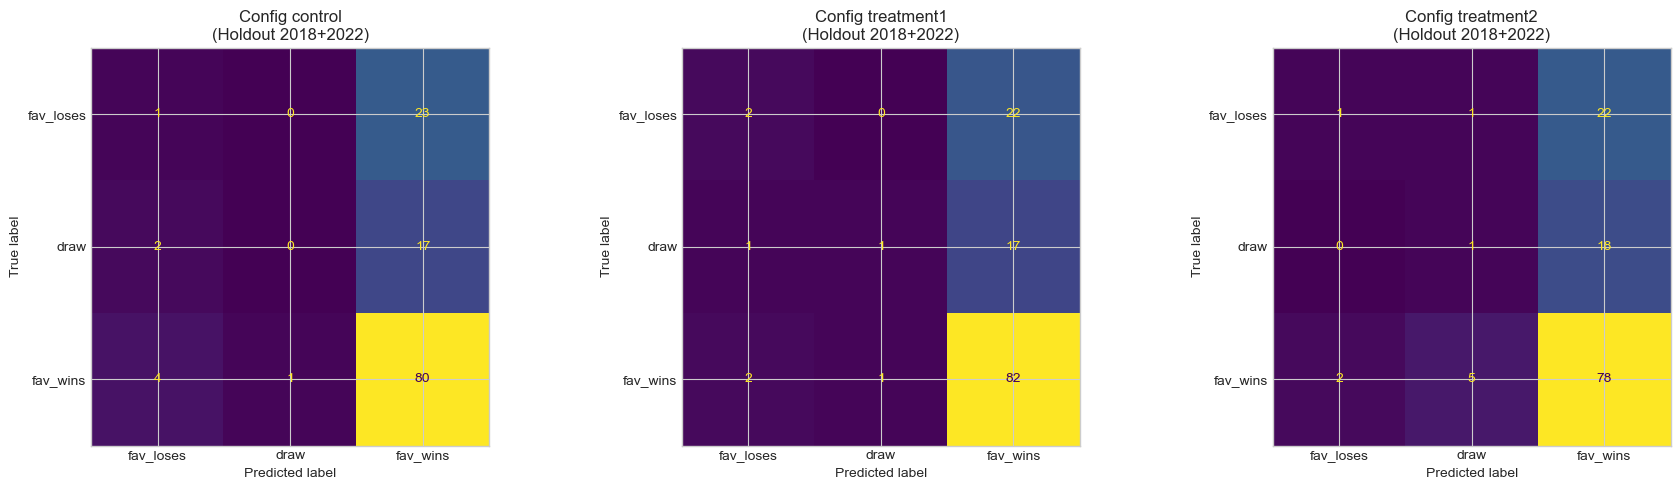

In [39]:
# ── Confusion matrices (holdout) ──────────────────────────────────────────
fig, axes = plt.subplots(1, len(best_models), figsize=(6 * len(best_models), 5))
if len(best_models) == 1:
    axes = [axes]
for ax, (cfg_name, entry) in zip(axes, best_models.items()):
    model = entry["model"]
    feat_cols = entry["features"]
    X_ho = holdout[feat_cols].values
    y_ho = holdout["y"].values
    y_pred = model.predict(X_ho)
    ConfusionMatrixDisplay.from_predictions(
        y_ho, y_pred, display_labels=CLASS_LABELS, ax=ax, colorbar=False
    )
    ax.set_title(f"Config {cfg_name}\n(Holdout 2018+2022)")
plt.tight_layout()
plt.savefig(DATA / "confusion_matrices_holdout.png", dpi=150, bbox_inches="tight")
plt.show()

## B7 — Results summary

Consolidated holdout performance across all three configurations.

Key questions:
- Does a wider training window (`control` → `treatment1`) improve accuracy?
- Does adding player/squad features (`control` → `treatment2`) help?


In [40]:
print("=== Holdout results — all configs ===")
display(
    holdout_df.style.format(
        {"Acc": "{:.3f}", "F1_macro": "{:.3f}", "AUC_macro": "{:.3f}"}
    ).highlight_max(subset=["Acc", "F1_macro", "AUC_macro"], color="#c6efce")
)

=== Holdout results — all configs ===


,Best_model,Acc,F1_macro,AUC_macro,n_features,train_from
Config,,,,,,
control,RF,0.633,0.282,0.569,47,2006
treatment1,RF,0.664,0.343,0.608,47,1998
treatment2,XGB,0.625,0.306,0.581,110,2006


---
## C — Anti-overfitting experiments

Two targeted interventions tested on top of the existing results — **original code above is unchanged**.

| Experiment | Idea | Scope |
|------------|------|-------|
| **C1 — Ensemble** | Weighted-average all 4 model probabilities (weights = LOTO AUC) instead of picking one winner | all 3 configs |
| **C2 — Regularized models** | Tighten tree depth, raise min-samples, add L1/L2 penalty | treatment1 (best config) |

Aim: shrink the CV→holdout gap without touching the original CONFIGS or MODELS.


### C1 — Ensemble: weighted probability average

Rather than picking the single LOTO winner, we fit **all four models** on the full
training set and average their `predict_proba` outputs weighted by LOTO macro-AUC.

**Why this helps with overfitting:** single-model selection amplifies CV variance —
the "winner" may have gotten lucky on 3–5 folds. Averaging reduces that variance
at near-zero cost, and usually never makes things worse.


In [ ]:
# Fit ALL 4 models on full training set for each config
# (best_models stores only the single CV winner; we need all 4 for the ensemble)
all_fitted_ens = {}
for cfg_name, cfg in CONFIGS.items():
    train = df_fav[
        (df_fav["year"] >= cfg["train_min_year"])
        & (~df_fav["year"].isin(HOLDOUT_YEARS))
    ]
    X_tr, y_tr = train[cfg["features"]], train["y"]
    all_fitted_ens[cfg_name] = {}
    for mn, mp in MODELS.items():
        m = clone(mp)
        m.fit(X_tr, y_tr)
        all_fitted_ens[cfg_name][mn] = m
    print(f"{cfg_name}: all 4 models fitted on {len(train)} rows")

# Ensemble holdout evaluation
ens_rows = []
for cfg_name, cfg in CONFIGS.items():
    X_ho = holdout[cfg["features"]].values
    y_ho = holdout["y"].values

    # Weights = LOTO macro-AUC (already in all_cv_results)
    aucs = {mn: all_cv_results[cfg_name][mn]["auc_mean"] for mn in MODELS}
    total_w = sum(aucs.values())

    # Weighted probability average
    proba = np.zeros((len(holdout), 3))
    for mn, m in all_fitted_ens[cfg_name].items():
        proba += (aucs[mn] / total_w) * m.predict_proba(X_ho)

    y_pred = proba.argmax(axis=1)
    yb = label_binarize(y_ho, classes=[0, 1, 2])

    weights_str = ", ".join(f"{mn}={aucs[mn]/total_w:.2f}" for mn in MODELS)
    print(f"\n{cfg_name} weights: {weights_str}")
    print(
        classification_report(y_ho, y_pred, target_names=CLASS_LABELS, zero_division=0)
    )

    ens_rows.append(
        {
            "Config": f"{cfg_name}_ens",
            "Best_model": "ensemble(4)",
            "Acc": accuracy_score(y_ho, y_pred),
            "F1_macro": f1_score(y_ho, y_pred, average="macro", zero_division=0),
            "AUC_macro": roc_auc_score(yb, proba, average="macro", multi_class="ovr"),
            "n_features": len(cfg["features"]),
            "train_from": cfg["train_min_year"],
        }
    )

ens_df = pd.DataFrame(ens_rows).set_index("Config")
print("\n=== C1 Ensemble — holdout summary ===")
display(
    ens_df.style.format({"Acc": "{:.3f}", "F1_macro": "{:.3f}", "AUC_macro": "{:.3f}"})
)

control: all 4 models fitted on 192 rows
treatment1: all 4 models fitted on 320 rows
treatment2: all 4 models fitted on 192 rows

control weights: LogReg=0.25, RF=0.27, LGBM=0.24, XGB=0.24
              precision    recall  f1-score   support

   fav_loses       0.29      0.08      0.13        24
        draw       0.07      0.05      0.06        19
    fav_wins       0.69      0.87      0.77        85

    accuracy                           0.60       128
   macro avg       0.35      0.34      0.32       128
weighted avg       0.52      0.60      0.55       128


treatment1 weights: LogReg=0.25, RF=0.26, LGBM=0.25, XGB=0.25
              precision    recall  f1-score   support

   fav_loses       0.25      0.08      0.12        24
        draw       0.21      0.21      0.21        19
    fav_wins       0.69      0.82      0.75        85

    accuracy                           0.59       128
   macro avg       0.38      0.37      0.36       128
weighted avg       0.54      0.59      0.

,Best_model,Acc,F1_macro,AUC_macro,n_features,train_from
Config,,,,,,
control_ens,ensemble(4),0.602,0.320,0.579,47,2006
treatment1_ens,ensemble(4),0.594,0.363,0.588,47,1998
treatment2_ens,ensemble(4),0.617,0.324,0.577,110,2006


### C2 — Regularized models (treatment1)

We re-run LOTO CV on **treatment1** (the best config) using tighter hyperparameters:

| Model | Key changes vs original |
|-------|------------------------|
| `LogReg_C01` | `C=0.1` (stronger L2, original default `C=1.0`) |
| `RF_reg` | `max_depth=5`, `min_samples_leaf=8` (original: unlimited depth, leaf=1) |
| `LGBM_reg` | `max_depth=4`, `min_child_samples=15`, `subsample=0.8`, `colsample_bytree=0.7` |
| `XGB_reg` | `max_depth=3`, `reg_alpha=0.5`, `reg_lambda=2.0`, `subsample=0.8`, `colsample_bytree=0.7` |

Then pick the best by LOTO AUC and evaluate on holdout.


In [ ]:
MODELS_REG = {
    "LogReg_C01": Pipeline(
        [
            ("imp", SimpleImputer()),
            ("sc", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    C=0.1,
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=SEED,
                ),
            ),
        ]
    ),
    "RF_reg": Pipeline(
        [
            ("imp", SimpleImputer()),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=5,
                    min_samples_leaf=8,
                    class_weight="balanced",
                    random_state=SEED,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "LGBM_reg": Pipeline(
        [
            ("imp", SimpleImputer()),
            (
                "clf",
                lgb.LGBMClassifier(
                    n_estimators=200,
                    max_depth=4,
                    min_child_samples=15,
                    subsample=0.8,
                    colsample_bytree=0.7,
                    class_weight="balanced",
                    random_state=SEED,
                    verbosity=-1,
                ),
            ),
        ]
    ),
    "XGB_reg": Pipeline(
        [
            ("imp", SimpleImputer()),
            (
                "clf",
                xgb.XGBClassifier(
                    n_estimators=200,
                    max_depth=3,
                    reg_alpha=0.5,
                    reg_lambda=2.0,
                    subsample=0.8,
                    colsample_bytree=0.7,
                    use_label_encoder=False,
                    eval_metric="mlogloss",
                    random_state=SEED,
                    verbosity=0,
                ),
            ),
        ]
    ),
}
print("MODELS_REG defined:", list(MODELS_REG.keys()))

MODELS_REG defined: ['LogReg_C01', 'RF_reg', 'LGBM_reg', 'XGB_reg']


In [ ]:
# LOTO CV — regularized models, treatment1 only
_cfg_name = "treatment1"
_cfg = CONFIGS[_cfg_name]
_train = df_fav[
    (df_fav["year"] >= _cfg["train_min_year"]) & (~df_fav["year"].isin(HOLDOUT_YEARS))
]

t0 = time.time()
reg_cv_results = loto_cv(_train, _cfg["features"], MODELS_REG)
print(f"Regularized LOTO done in {time.time()-t0:.0f}s\n")

# Side-by-side: original vs regularized
orig_rows = []
for mn in MODELS:
    r = all_cv_results[_cfg_name][mn]
    orig_rows.append(
        {
            "Model": f"{mn} (original)",
            "Acc": f"{r['acc_mean']:.3f} ± {r['acc_std']:.3f}",
            "F1": f"{r['f1_mean']:.3f}  ± {r['f1_std']:.3f}",
            "AUC": f"{r['auc_mean']:.3f} ± {r['auc_std']:.3f}",
        }
    )

reg_rows = []
for mn, r in reg_cv_results.items():
    reg_rows.append(
        {
            "Model": f"{mn} (regularized)",
            "Acc": f"{r['acc_mean']:.3f} ± {r['acc_std']:.3f}",
            "F1": f"{r['f1_mean']:.3f}  ± {r['f1_std']:.3f}",
            "AUC": f"{r['auc_mean']:.3f} ± {r['auc_std']:.3f}",
        }
    )

print("--- treatment1 LOTO CV comparison ---")
display(pd.DataFrame(orig_rows + reg_rows).set_index("Model"))

Regularized LOTO done in 8s

--- treatment1 LOTO CV comparison ---


,Acc,F1,AUC
Model,,,
LogReg (original),0.506 ± 0.057,0.442 ± 0.052,0.711 ± 0.035
RF (original),0.669 ± 0.035,0.384 ± 0.060,0.744 ± 0.059
LGBM (original),0.637 ± 0.064,0.494 ± 0.035,0.720 ± 0.057
XGB (original),0.631 ± 0.090,0.429 ± 0.071,0.723 ± 0.056
LogReg_C01 (regularized),0.509 ± 0.032,0.442 ± 0.044,0.718 ± 0.041
RF_reg (regularized),0.619 ± 0.074,0.522 ± 0.073,0.749 ± 0.052
LGBM_reg (regularized),0.634 ± 0.081,0.478 ± 0.065,0.709 ± 0.042
XGB_reg (regularized),0.641 ± 0.062,0.444 ± 0.042,0.712 ± 0.041


In [ ]:
# Pick best regularized model by LOTO AUC and evaluate on holdout
_best_reg_name = max(reg_cv_results, key=lambda k: reg_cv_results[k]["auc_mean"])
_best_reg_auc = reg_cv_results[_best_reg_name]["auc_mean"]
_orig_best = best_models[_cfg_name]["model_name"]
_orig_auc = all_cv_results[_cfg_name][_orig_best]["auc_mean"]

print(f"Best regularized model : {_best_reg_name} (LOTO AUC {_best_reg_auc:.3f})")
print(f"Original best model    : {_orig_best}    (LOTO AUC {_orig_auc:.3f})")

# Refit on full training set
_best_reg_model = clone(MODELS_REG[_best_reg_name])
_best_reg_model.fit(_train[_cfg["features"]], _train["y"])

# Holdout
X_ho = holdout[_cfg["features"]].values
y_ho = holdout["y"].values
y_pred = _best_reg_model.predict(X_ho)
y_prob = _best_reg_model.predict_proba(X_ho)
yb = label_binarize(y_ho, classes=[0, 1, 2])

print(f"\nConfig treatment1_reg [{_best_reg_name}] — holdout 2018+2022")
print(classification_report(y_ho, y_pred, target_names=CLASS_LABELS, zero_division=0))

reg_holdout_row = {
    "Config": "treatment1_reg",
    "Best_model": _best_reg_name,
    "Acc": accuracy_score(y_ho, y_pred),
    "F1_macro": f1_score(y_ho, y_pred, average="macro", zero_division=0),
    "AUC_macro": roc_auc_score(yb, y_prob, average="macro", multi_class="ovr"),
    "n_features": len(_cfg["features"]),
    "train_from": _cfg["train_min_year"],
}

Best regularized model : RF_reg (LOTO AUC 0.749)
Original best model    : RF    (LOTO AUC 0.744)

Config treatment1_reg [RF_reg] — holdout 2018+2022
              precision    recall  f1-score   support

   fav_loses       0.19      0.12      0.15        24
        draw       0.18      0.37      0.24        19
    fav_wins       0.74      0.64      0.68        85

    accuracy                           0.50       128
   macro avg       0.37      0.38      0.36       128
weighted avg       0.55      0.50      0.52       128



### C3 — Full comparison

All methods side by side. Green = column maximum.

Rows:
- **single-best** — original: one winner selected by LOTO AUC (existing code)
- **ensemble** — C1: weighted average of all 4 models  
- **regularized** — C2: tighter hyperparams, one winner selected by LOTO AUC


In [ ]:
# Build full comparison table
_orig = holdout_df.copy()
_orig.insert(0, "method", "single-best")

_ens = ens_df.copy()
_ens.insert(0, "method", "ensemble")

_reg = pd.DataFrame([reg_holdout_row]).set_index("Config")
_reg.insert(0, "method", "regularized")

comparison_df = pd.concat([_orig, _ens, _reg])

# Highlight max per metric
print("=== Full comparison — holdout 2018+2022 ===")
display(
    comparison_df[
        [
            "method",
            "Best_model",
            "Acc",
            "F1_macro",
            "AUC_macro",
            "n_features",
            "train_from",
        ]
    ]
    .style.format({"Acc": "{:.3f}", "F1_macro": "{:.3f}", "AUC_macro": "{:.3f}"})
    .highlight_max(subset=["Acc", "F1_macro", "AUC_macro"], color="#c6efce")
)

=== Full comparison — holdout 2018+2022 ===


,method,Best_model,Acc,F1_macro,AUC_macro,n_features,train_from
Config,,,,,,,
control,single-best,RF,0.633,0.282,0.569,47,2006
treatment1,single-best,RF,0.664,0.343,0.608,47,1998
treatment2,single-best,XGB,0.625,0.306,0.581,110,2006
control_ens,ensemble,ensemble(4),0.602,0.320,0.579,47,2006
treatment1_ens,ensemble,ensemble(4),0.594,0.363,0.588,47,1998
treatment2_ens,ensemble,ensemble(4),0.617,0.324,0.577,110,2006
treatment1_reg,regularized,RF_reg,0.500,0.358,0.604,47,1998


---
## D — Key Conclusions

### D1 — What the experiments show

All holdout results (2018 + 2022, 128 matches) fall in a tight AUC band of **0.57–0.61**.
No single intervention moved the needle by more than ~0.04 AUC. The table below
summarises the three experiments:

| Method | Best config | Acc | F1_macro | AUC_macro | Verdict |
|--------|-------------|-----|----------|-----------|---------|
| Single-best (original) | treatment1 RF | **0.664** | 0.343 | **0.608** | Best overall accuracy |
| Ensemble (C1) | treatment1 | 0.594 | **0.363** | 0.588 | Best minority-class F1 |
| Regularized (C2) | treatment1 RF_reg | 0.500 | 0.358 | 0.604 | Best draw recall (0.37) |

### D2 — Three structural findings

**Finding 1 — More samples beats more features.**
`treatment1` (1998–2014, team-only, 320 rows) consistently outperforms or matches
`treatment2` (2006–2014, team+player/squad, 192 rows) on all holdout metrics.
Adding 63 player/squad features while halving the training window is not a
beneficial trade-off at this data scale.

**Finding 2 — The CV→holdout gap is driven by distribution shift, not just overfitting.**
Regularization (C2) did not shrink the LOTO↔holdout AUC gap
(0.136 original RF → 0.145 RF_reg). This implies the gap is structural:
2018/2022 football dynamics (VAR, expanded squads, tactical evolution) differ
from the 1998–2014 training period in ways that features cannot fully capture.

**Finding 3 — Draw prediction is a persistent ceiling.**
All configurations achieve draw recall < 0.10 with the single-best selection.
The regularized model (RF_reg) improves draw recall to **0.37** by trading
accuracy on fav_wins, but macro-F1 only rises from 0.343 → 0.358.
Draw outcomes remain inherently under-determined by pre-match features.

### D3 — Final model choice

**`treatment1` with default RF** is the selected model going forward:
- Highest holdout accuracy (0.664) and AUC (0.608)
- Training window 1998–2014, 47 team-level features
- Interpretability is not sacrificed by high dimensionality (treatment2's 110 features)

This model is used in `04_interpretability.ipynb` for SHAP, LIME, and edge-case analysis.

### D4 — What ensemble and regularization tell us about the problem

The ensemble's draw recall improvement (0.05 → 0.21) and regularization's draw
recall jump (0.05 → 0.37) confirm that **the model architecture can "see" draws** —
it simply suppresses them when optimising accuracy against a 65%-majority class.
This is a calibration and class-weighting problem, not a feature-information problem.
Future work could explore probability calibration (Platt scaling, isotonic regression)
specifically tuned to balance draw vs win prediction.